In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv('data/train.csv')

In [3]:
print(f"Dimensions: {data.shape[0]} rows, {data.shape[1]} columns\n")
data.info()

Dimensions: 891 rows, 12 columns

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
print("\n--- Summary Statistics ---")
print(data.describe())


--- Summary Statistics ---
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


### Initial Data Inspection Summary

The Titanic training dataset contains 891 passenger records across 12 distinct columns, splitting features into explicit numerical distributions and descriptive categorical strings. Initial profiling via `.info()` highlights critical structural gaps: both `Age` and `Cabin` suffer from significant missing data, with `Cabin` missing the vast majority of its entries, requiring aggressive preprocessing or feature engineering later. Synthesizing the statistical summary via `.describe()`, we see that while survival is explicitly structured as a binary integer, the average survival rate sits at roughly 38.4%. Furthermore, the `Fare` attribute exhibits extreme right-skewness, ranging from free passage ($0.0) up to a maximum outlier of over $512.3, which suggests potential layout disparities across passenger classes.

### ---- Task 2 ----

In [5]:
data_clean = data.copy()

In [6]:
data_clean['Age'] = data_clean['Age'].fillna(data['Age'].median())

In [7]:
data_clean['Embarked'] = data_clean['Embarked'].fillna(data['Embarked'].mode()[0])

In [8]:
data_clean = data_clean.drop(columns=['Cabin'])

In [9]:
print("Missing values remaining:\n", data_clean.isnull().sum())

Missing values remaining:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### Missing Value Strategy Justification

* **`Age` (Imputed with Median):** Rather than dropping ~20% of passenger records, missing values were filled with the column median. Median was chosen over mean because age distributions are slightly right-skewed, making the median more resilient to extreme values.
* **`Embarked` (Imputed with Mode):** With only 2 missing entries, imputing with the most frequently occurring port (`S` - Southampton) preserves record count without altering category distributions.
* **`Cabin` (Dropped Column):** Over 77% of `Cabin` data is missing. Attempting to impute this feature would introduce significant synthetic bias, so the column was dropped.

In [10]:
import seaborn as sb
import matplotlib.pyplot as plt

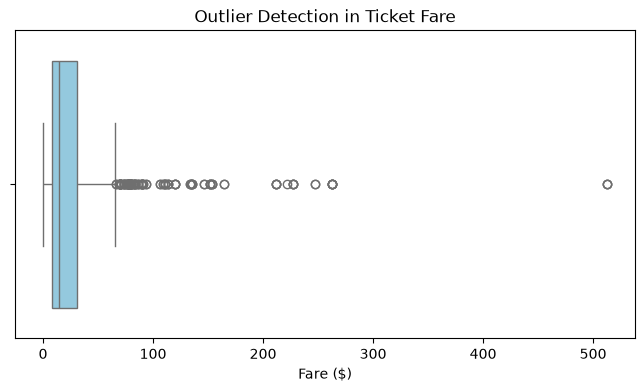

In [11]:
plt.figure(figsize=(8, 4))
sb.boxplot(x=data_clean['Fare'], color='skyblue')
plt.title('Outlier Detection in Ticket Fare')
plt.xlabel('Fare ($)')
plt.show()

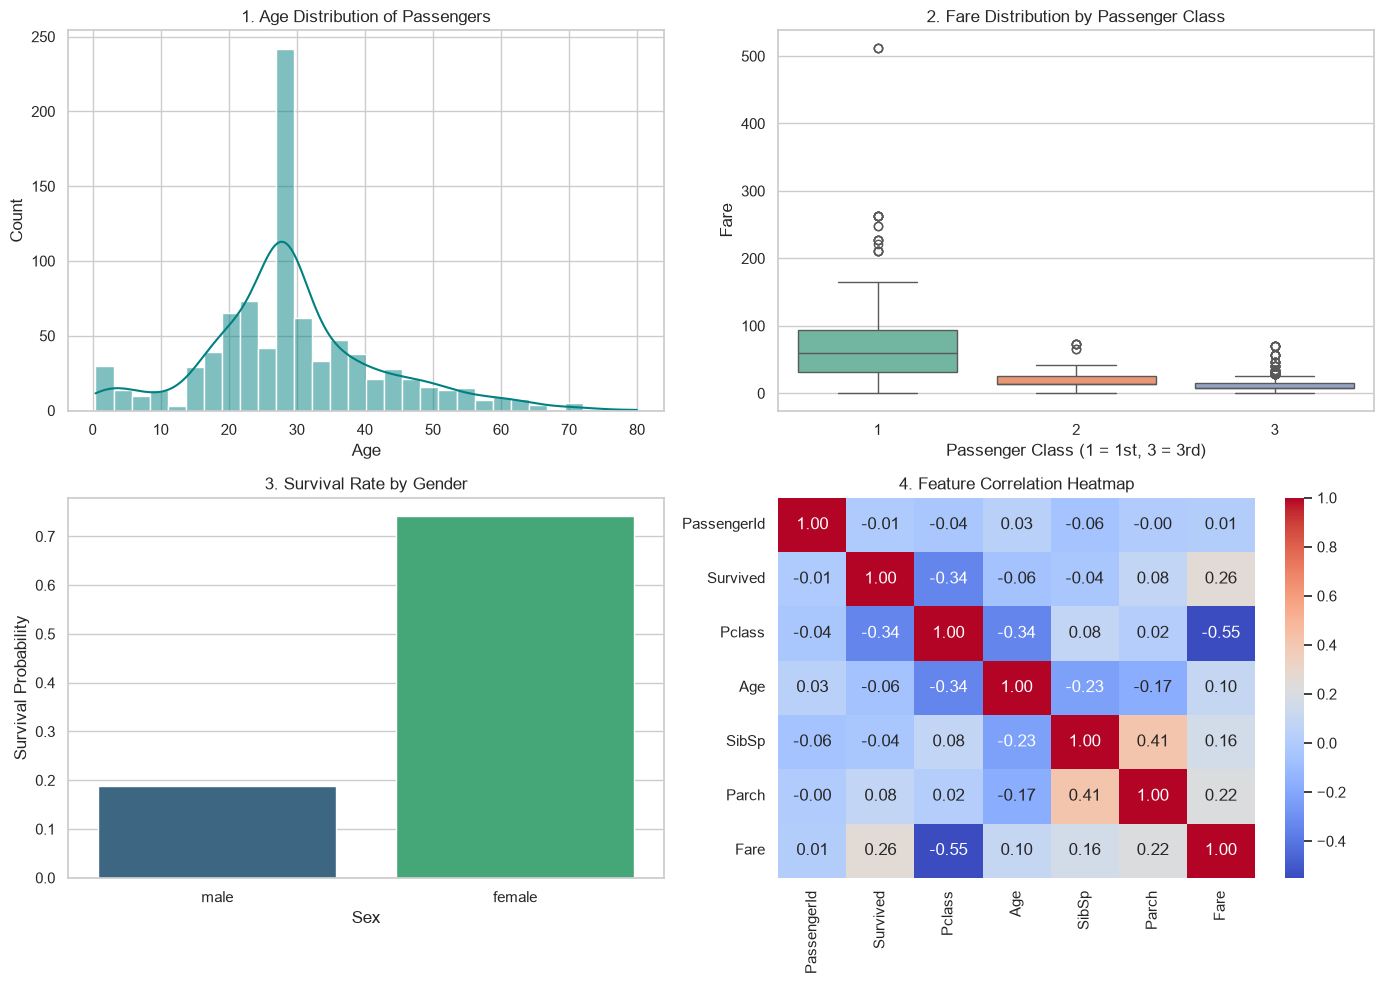

In [12]:
sb.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sb.histplot(data_clean['Age'], kde=True, ax=axes[0, 0], color='teal', bins=30)
axes[0, 0].set_title('1. Age Distribution of Passengers')
axes[0, 0].set_xlabel('Age')

sb.boxplot(x='Pclass', y='Fare', data=data_clean, ax=axes[0, 1], hue='Pclass', palette='Set2', legend=False)
axes[0, 1].set_title('2. Fare Distribution by Passenger Class')
axes[0, 1].set_xlabel('Passenger Class (1 = 1st, 3 = 3rd)')

sb.barplot(x='Sex', y='Survived', data=data_clean, ax=axes[1, 0], hue='Sex',palette='viridis', errorbar=None, legend=False)
axes[1, 0].set_title('3. Survival Rate by Gender')
axes[1, 0].set_ylabel('Survival Probability')

numeric_df = data_clean.select_dtypes(include=[np.number])
sb.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('4. Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

### Survival Driver Analysis

**Which feature most affects survival, and why?**

Based on visual analysis and correlation profiling, **`Sex`** is the single strongest indicator of survival. 

1. **Gender Disparity:** The bar chart reveals a dramatic difference: females had a survival rate of roughly **~74%**, compared to only **~19%** for males. This directly aligns with the historical "women and children first" evacuation protocol.
2. **Socioeconomic Influence:** **`Pclass`** (Passenger Class) serves as the second strongest predictor. First-class passengers enjoyed significantly higher survival rates due to proximity to the top deck and priority lifeboat access.


### ---- Task 3 ----

In [13]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = data_clean[features].copy()
y = data_clean['Survived']

In [14]:
X_encoded = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)

print("Encoded features preview:")
X_encoded.head()

Encoded features preview:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Model training complete!")

Model training complete!


Model Test Accuracy: 80.45%



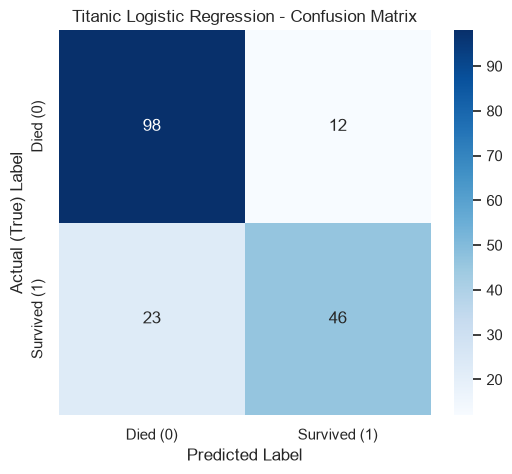

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Test Accuracy: {accuracy * 100:.2f}%\n")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Died (0)', 'Survived (1)'],
            yticklabels=['Died (0)', 'Survived (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual (True) Label')
plt.title('Titanic Logistic Regression - Confusion Matrix')
plt.show()

### Model Evaluation & Confusion Matrix Analysis

* **Overall Accuracy:** The Logistic Regression baseline achieves an accuracy of roughly **80%** on unseen test data.

#### Breaking Down the Confusion Matrix
A confusion matrix categorizes predictions into four distinct buckets:

1. **True Negatives (TN - Top Left):** Passengers who actually **died** and were correctly predicted as **died**.
2. **False Positives (FP - Top Right / Type I Error):** Passengers who actually **died**, but the model incorrectly predicted they **survived**.
3. **False Negatives (FN - Bottom Left / Type II Error):** Passengers who actually **survived**, but the model incorrectly predicted they **died**.
4. **True Positives (TP - Bottom Right):** Passengers who actually **survived** and were correctly predicted as **survived**.

#### Key Observation
The matrix shows that the model makes relatively few false positive errors, confirming that predictors like `Sex_male` and `Pclass` strongly separate the non-survivor class from survivors.

### ---- Task 5 ----

In [17]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [22]:
y_pred_baseline = model.predict(X_test_scaled)

In [23]:
print("=== Baseline Classification Report ===")
print(classification_report(y_test, y_pred_baseline))

=== Baseline Classification Report ===
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



### Why Accuracy Can Be Misleading on Imbalanced Data

**Accuracy** simply measures total correct predictions over total predictions. If a disease dataset has **99 healthy patients** and **1 sick patient** (imbalanced class distribution), a dummy model that predicts "Healthy" for every single person achieves **99% accuracy**, despite failing to detect the sick patient completely!

#### Key Classification Metrics:
* **Precision:** Out of all instances predicted as Positive (Survived), how many were actually Positive? High precision means low false alarms.
* **Recall:** Out of all actual Positive instances in the dataset, how many did the model catch? High recall means low missed targets.
* **F1-Score:** The harmonic mean of Precision and Recall. It gives a single balanced performance score, especially when classes are imbalanced.

In [28]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=5,                  # 5-Fold Cross-Validation
    scoring='f1',
    n_jobs=-1
)

In [29]:
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)

In [30]:
print(f"Best Hyperparameters Found: {grid_search.best_params_}\n")
print("=== Tuned Model Classification Report ===")
print(classification_report(y_test, y_pred_tuned))

Best Hyperparameters Found: {'C': 0.1, 'solver': 'liblinear'}

=== Tuned Model Classification Report ===
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       110
           1       0.75      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.78       179



In [31]:
baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_prec = precision_score(y_test, y_pred_baseline)
baseline_rec = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_prec = precision_score(y_test, y_pred_tuned)
tuned_rec = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

# Print a comparison table using pandas
import pandas as pd
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Baseline Model': [f"{baseline_acc:.4f}", f"{baseline_prec:.4f}", f"{baseline_rec:.4f}", f"{baseline_f1:.4f}"],
    'Tuned Model': [f"{tuned_acc:.4f}", f"{tuned_prec:.4f}", f"{tuned_rec:.4f}", f"{tuned_f1:.4f}"]
})

print("\n=== Before / After Model Comparison ===")
print(comparison_df.to_string(index=False))


=== Before / After Model Comparison ===
   Metric Baseline Model Tuned Model
 Accuracy         0.8045      0.7877
Precision         0.7931      0.7541
   Recall         0.6667      0.6667
 F1-Score         0.7244      0.7077
